##  EV Market & Emissions Analysis
---
##  **Project Overview**
This project explores how fluctuations in U.S. gasoline prices influence consumer behavior in the electric and hybrid vehicle market, as well as their environmental impact. It focuses on the period from 2000 to 2024, examining whether spikes in fuel prices correspond to increased adoption of electric and hybrid vehicles and how this shift contributes to a decline in national vehicle emissions. Building on the initial analysis, I developed predictive models using lag features and time-series data to forecast the EV sales market for 2025-2030. The models explore the relationship between EV sales and gasoline prices by testing different training periods (2000-2024 vs. 2020-2024) and different gas price scenarios (low, baseline, and high) to see how these factors influence future predictions and model accuracy.
.

---

##  **Datasets Used**
**EV&hybrid car sales data:** This dataset comes from the U.S. Bureau of Transportation Statistics. It provides yearly sales numbers for HEV, PHEV, BEV, and fuel-cell vehicles from 1999–2024. The data is sourced from Argonne National Laboratory and is part of the official Transportation Statistics Annual Report, which makes it reliable and accurate. I used this dataset to track how EV/Hybrid sales changed over time and compare it with gasoline prices and emissions.


 https://www.bts.gov/browse-statistical-products-and-data/info-gallery/sales-hybrid-plug-hybrid-and-battery-evs-1999?utm_source=chatgpt.com

**Gasoline price data:** This dataset comes from the U.S. Department of Energy's Alternative Fuels Data Center (AFDC). It provides average monthly U.S. retail fuel prices — including gasoline — from 2000 to 2025. The data is sourced from the Clean Cities Alternative Fuel Price Reports, which makes it reliable and consistently updated for public use.

https://afdc.energy.gov/fuels/prices.html

**emissions:** This dataset comes from the U.S. Bureau of Transportation Statistics (BTS). It provides estimated U.S. average vehicle emissions rates — including CO₂ and NOx — measured in grams per mile. The data is based on the EPA's MOVES emissions model and includes yearly estimates for gasoline and diesel vehicles. Because this dataset is produced using national EPA standards and official modeling methods, it is considered reliable for understanding long-term emission trends.

https://www.bts.gov/content/estimated-national-average-vehicle-emissions-rates-vehicle-vehicle-type-using-gasoline-and

---

## **Predictive Analysis:**
After analyzing the historical data and seeing the patterns between gas prices, EV sales, and emissions, I wanted to take it a step further and try predicting what the EV market might look like over the next few years. For this part, I used time-series forecasting with lag features, which basically means I'm using data from previous years to predict future sales.

The reason lag features make sense here is that there's a lot of momentum in the EV market. If sales were high last year, that momentum carries over—more charging stations get built, more people talk about EVs with their friends and family, dealerships start stocking more models, and so on. The same logic applies to gas prices. If gas was expensive last year, people remember that when they're deciding what car to buy this year.

I wanted to see whether the amount of historical data used to train the model affected the predictions, so I compared two training periods: 2000–2024 and 2020–2024. The full 2000–2024 dataset captures the entire history of EV adoption, including the slow growth in the early years, while the 2020–2024 dataset focuses only on the recent surge in EV sales. The predictions from these two models were very different.

I also tested how different gas price scenarios would affect EV adoption, since gas prices are highly unpredictable and influenced by factors like wars, economic conditions, and government policies. I ran three scenarios—low, baseline, and high gas prices—and found that gas prices had a significant impact on EV sales.

I manually downloaded each dataset from the official websites and cleaned them in Excel, keeping only the parts that were relevant for this project. When I submit my Final Project, I will include both the original datasets and my cleaned versions. The cleaned files are the ones I uploaded here for the analysis.

In [55]:
import pandas as pd

# Loading cleaned EV & Hybrid sales data
ev_hybrid_sales = pd.read_excel("ev_hybrid_sales.xlsx")
print(" EV & Hybrid Sales Data Loaded:")
display(ev_hybrid_sales.head())

# Loading cleaned Emission data (NOx + CO2)
emissions = pd.read_excel("emissions.xlsx")
print(" Emission Data Loaded:")
display(emissions.head())

# Loading cleaned Gasoline price data
gas_prices = pd.read_excel("gas_prices.xlsx")
print(" Gasoline Price Data Loaded:")
display(gas_prices.head())


 EV & Hybrid Sales Data Loaded:


,Unnamed: 0,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 27,Unnamed: 28
0,"Total HEV, PHEV, and BEV",17.0,9350.0,20282.0,36042.0,47566.0,84233.0,205876.0,251864.0,351071.0,...,560762,671462,721146,763594,1436252,1700567,2619728,1430282,NaN,NaN
1,Hybrid electric vehicle (HEV),17.0,9350.0,20282.0,36042.0,47566.0,84233.0,205876.0,251864.0,351071.0,...,362868,338149,399444,455067,798992,766412,1175597,713126,NaN,0.959224
2,“Plug-in” hybrid electric vehicles (PHEV),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,91089,123883,85791,69049,174453,183411,295937,170572,NaN,1.051349
3,Battery electric-only vehicles (BEV),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,104492,207062,233822,238540,459466,747982,1145216,546262,NaN,1.627938
4,Fuel cell vehicles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2313,2368,2089,938,3341,2762,2978,322,NaN,0.826699


 Emission Data Loaded:


,Unnamed: 0,(R) 2000,(R) 2001,(R) 2002,(R) 2003,(R) 2004,(R) 2005,(R) 2006,(R) 2007,(R) 2008,...,(R) 2021,(P) 2022,(P) 2023,(P) 2024,(P) 2025,(P) 2026,(P) 2027,(P) 2028,(P) 2029,(P) 2030
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Exhaust NOx,2.413,2.294,2.146,2.032,1.820,1.619,1.496,1.344,1.282,...,0.208,0.187,0.168,0.150,0.135,0.121,0.109,0.100,0.092,0.089
2,Exhaust CO2,443.169,439.732,434.057,429.877,426.587,423.489,420.920,418.543,418.056,...,362.181,356.553,349.218,342.263,334.793,327.170,319.767,311.861,304.084,296.281


 Gasoline Price Data Loaded:


,"Average Retail Fuel Prices in the United States (in Gasoline Gallon Equivalents, GGEs)",Unnamed: 1
0,Report Date,Gasoline
1,4/10/00,1.516
2,10/9/00,1.541
3,6/4/01,1.679
4,10/22/01,1.265


After uploading all three datasets, I noticed that each one had a completely different structure. The rows, columns, and variable formats didn’t line up with each other at all. Since the whole goal of this project is to combine multiple datasets to make clear, meaningful graphs, I needed to clean and reshape everything into a consistent format first.

Each dataset required a different kind of wrangling. The EV/Hybrid sales data came in a wide format, so I reorganized it into a long, year-based structure. The emissions dataset also needed restructuring so I could isolate the CO₂ and NOx values by year.

The gasoline price dataset was the most different because it reported prices by specific dates (monthly/daily). To make it usable, I converted the date column into Python datetime objects, extracted the year, and then calculated the average gasoline price for each year.

Once all three datasets were cleaned and reshaped into the same yearly format, I could finally merge them and start analyzing the relationships between gasoline prices, EV/Hybrid sales, and emissions.

I will clean up the gasoline price data first.

In [56]:
# Cleaning Gasoline price data

# Rename columns to simpler names
gas_prices = gas_prices.rename(columns={
    'Average Retail Fuel Prices in the United States (in Gasoline Gallon Equivalents, GGEs)': 'date',
    'Unnamed: 1': 'gas_price'
})

# Convert date column to datetime
gas_prices['date'] = pd.to_datetime(gas_prices['date'], errors='coerce')

# Drop rows where date is missing
gas_prices = gas_prices.dropna(subset=['date'])

# Extract year
gas_prices['year'] = gas_prices['date'].dt.year

# Average gasoline price by year
gas_yearly = gas_prices.groupby('year', as_index=False)['gas_price'].mean()

display(gas_yearly.head())


/tmp/ipython-input-1026992115.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gas_prices['date'] = pd.to_datetime(gas_prices['date'], errors='coerce')


,year,gas_price
0,2000,1.5285
1,2001,1.472
2,2002,1.34125
3,2003,1.5415
4,2004,1.897333


Now I will clean up the EV/Hybrid sales dataset.

> This dataset came in a wide format with each vehicle type as a separate column, so I reshaped it into a tidy, year-based format. I extracted the year, organized the columns, and cleaned the values so the data matches the same yearly structure as the other datasets.

In [57]:
# Cleaning EV & Hybrid sales data

ev = ev_hybrid_sales.copy()

# Melt the EV dataset (wide → long)
ev_long = ev.melt(id_vars=ev.columns[0], var_name="year", value_name="sales")

# Extract the year number
ev_long["year"] = ev_long["year"].astype(str).str.extract(r"(\d{4})")
ev_long = ev_long.dropna(subset=["year"])
ev_long["year"] = ev_long["year"].astype(int)

# Pivot so each category is a column
ev_clean = ev_long.pivot_table(index="year", columns=ev.columns[0], values="sales").reset_index()

# Rename total sales column (adjust name based on your file)
ev_clean = ev_clean.rename(columns={
    'Total HEV, PHEV, and BEV': 'total_sales'
})

display(ev_clean.head())


Unnamed: 0,year,Battery electric-only vehicles (BEV),Fuel cell vehicles,Hybrid electric vehicle (HEV),total_sales,“Plug-in” hybrid electric vehicles (PHEV)
0,1999,NaN,NaN,17.0,17.0,NaN
1,2000,NaN,NaN,9350.0,9350.0,NaN
2,2001,NaN,NaN,20282.0,20282.0,NaN
3,2002,NaN,NaN,36042.0,36042.0,NaN
4,2003,NaN,NaN,47566.0,47566.0,NaN


Now I will merge the cleaned gasoline price data with the EV/Hybrid total sales dataset so they can be analyzed together.

In [58]:
# Merge gasoline price with total EV sales
merged = pd.merge(gas_yearly, ev_clean[['year', 'total_sales']], on='year', how='inner')

display(merged.head())


,year,gas_price,total_sales
0,2000,1.5285,9350.0
1,2001,1.472,20282.0
2,2002,1.34125,36042.0
3,2003,1.5415,47566.0
4,2004,1.897333,84233.0


Now we will make the graph

Since gasoline prices are only around 1dollar to 4dollar, but EV/Hybrid sales range from 0 to over 2.6 million, the two variables are on completely different scales.
If I put them on the same y-axis, the gasoline price line would look almost flat and hard to interpret.

To fix this, I used a dual-axis line chart **(I looked it up on online how to dual-axis)**:

one y-axis for gasoline price

the other y-axis for total EV/Hybrid sales

This makes it easier to see how changes in gasoline prices line up with changes in EV/Hybrid sales.

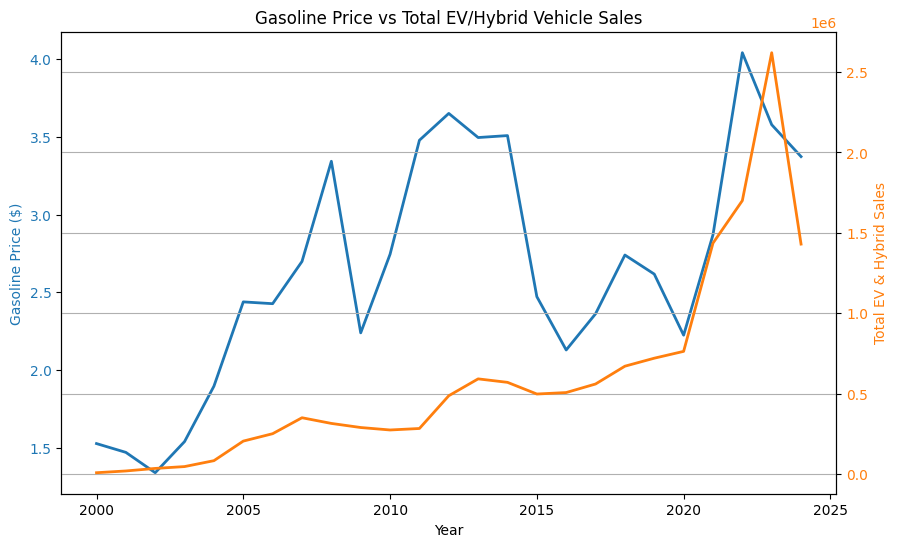

In [59]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# First line: Gasoline price
ax1.set_xlabel('Year')
ax1.set_ylabel('Gasoline Price ($)', color='tab:blue')
ax1.plot(merged['year'], merged['gas_price'], color='tab:blue', linewidth=2, label='Gasoline Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Second y-axis: EV/Hybrid sales
ax2 = ax1.twinx()
ax2.set_ylabel('Total EV & Hybrid Sales', color='tab:orange')
ax2.plot(merged['year'], merged['total_sales'], color='tab:orange', linewidth=2, label='Total Sales')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Gasoline Price vs Total EV/Hybrid Vehicle Sales')
plt.grid(True)
plt.show()


#Observation (Gasoline Price vs Total Sales)
The line chart compares the total number of hybrid and electric vehicle (HEV, PHEV, and BEV) sales with average U.S. gasoline prices from 2000 to 2024. Overall, the graph shows a pattern where increases in gasoline prices often line up with higher EV and hybrid vehicle sales.

A clear example is between 2020 and 2022, when gasoline prices rose sharply and EV/Hybrid sales increased around the same time. This suggests that when gas prices rise, more people consider switching to electric or hybrid vehicles.

However, this doesn't prove that gasoline prices directly caused the increase in EV sales. Other factors—such as new EV models, government incentives, and improvements in charging infrastructure—could also have contributed to the growth. Still, we can see there is a noticeable correlation between the two trends.

Now I will clean up the emissions dataset.

> This emissions dataset also came in a wide format, with different pollutants stored in separate columns. To make it usable with the other datasets, I reshaped it into a long, year-based format. I extracted the year from the column names, separated CO₂ and NOx into their own columns, and organized everything into a clean yearly structure. This puts the emissions data in the same format as the gasoline and EV/Hybrid datasets, making comparison and merging possible.

In [60]:
# Clean Emissions Data

em = emissions.copy()

# Melt wide → long
em_long = em.melt(id_vars=em.columns[0], var_name="year", value_name="value")

# Extract year from column names
em_long["year"] = em_long["year"].astype(str).str.extract(r"(\d{4})")
em_long = em_long.dropna(subset=["year"])
em_long["year"] = em_long["year"].astype(int)

# Pivot so NOx and CO2 become separate columns
em_clean = em_long.pivot_table(index="year", columns=em.columns[0], values="value").reset_index()

# Rename columns for convenience
em_clean = em_clean.rename(columns={
    "Exhaust NOx": "NOx",
    "Exhaust CO2": "CO2"
})

display(em_clean.head())


Unnamed: 0,year,CO2,NOx
0,2000,443.169,2.413
1,2001,439.732,2.294
2,2002,434.057,2.146
3,2003,429.877,2.032
4,2004,426.587,1.820


Now we are going to merge emissions data with EV/Hybrid sales data

In [61]:
# Merge EV sales with emissions data
emerged = pd.merge(ev_clean[["year", "total_sales"]], em_clean, on="year", how="inner")
display(emerged.head())


Unnamed: 0,year,total_sales,CO2,NOx
0,2000,9350.0,443.169,2.413
1,2001,20282.0,439.732,2.294
2,2002,36042.0,434.057,2.146
3,2003,47566.0,429.877,2.032
4,2004,84233.0,426.587,1.820


Now we are going to graph this. Since there are two different emission variables (CO₂ and NOₓ), I will create two separate graphs: one comparing CO₂ emissions with total EV/Hybrid sales, and another comparing NOₓ emissions with total EV/Hybrid sales. This makes each trend easier to see and avoids overcrowding both variables on a single chart.

First, let's look at CO₂ emissions:

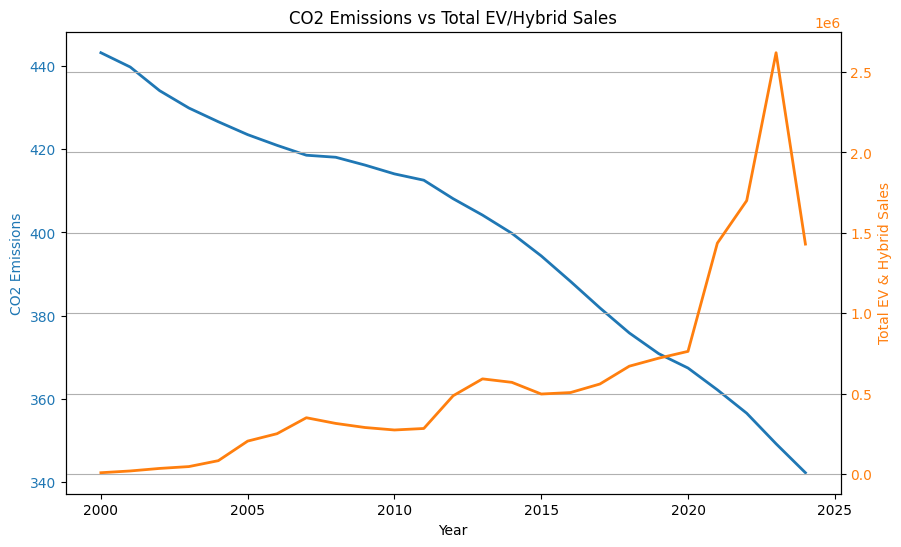

In [62]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# First axis: CO2 emissions
ax1.set_xlabel("Year")
ax1.set_ylabel("CO2 Emissions", color="tab:blue")
ax1.plot(emerged["year"], emerged["CO2"], color="tab:blue", linewidth=2, label="CO2")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Second axis: total EV sales
ax2 = ax1.twinx()
ax2.set_ylabel("Total EV & Hybrid Sales", color="tab:orange")
ax2.plot(emerged["year"], emerged["total_sales"], color="tab:orange", linewidth=2, label="Total Sales")
ax2.tick_params(axis='y', labelcolor="tab:orange")

plt.title("CO2 Emissions vs Total EV/Hybrid Sales")
plt.grid(True)
plt.show()


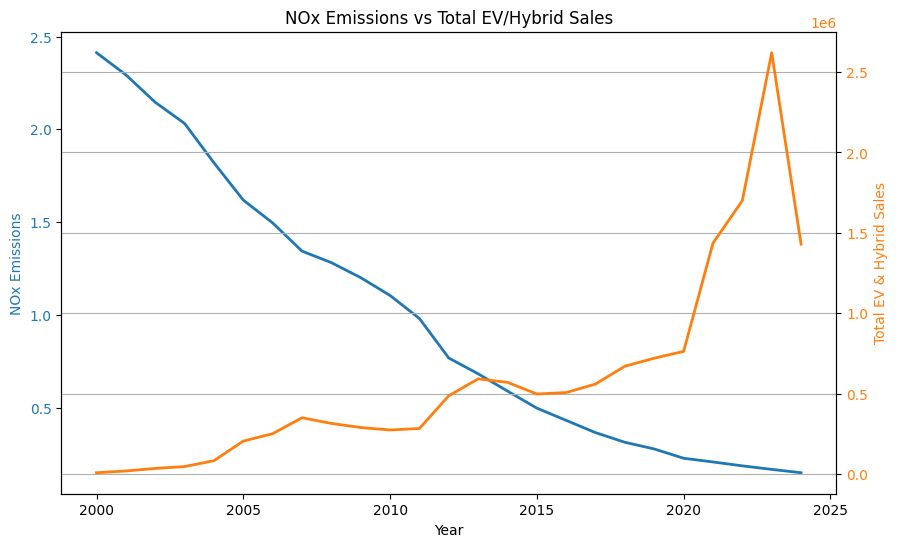

In [63]:
fig, ax1 = plt.subplots(figsize=(10,6))

# First axis: NOx emissions
ax1.set_xlabel("Year")
ax1.set_ylabel("NOx Emissions", color="tab:blue")
ax1.plot(emerged["year"], emerged["NOx"], color="tab:blue", linewidth=2, label="NOx")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Second axis: total EV sales
ax2 = ax1.twinx()
ax2.set_ylabel("Total EV & Hybrid Sales", color="tab:orange")
ax2.plot(emerged["year"], emerged["total_sales"], color="tab:orange", linewidth=2, label="Total Sales")
ax2.tick_params(axis='y', labelcolor="tab:orange")

plt.title("NOx Emissions vs Total EV/Hybrid Sales")
plt.grid(True)
plt.show()


#Observation (CO₂ and NOx Emissions vs Total Sales)

The two line charts compare total hybrid and electric vehicle sales with CO₂ and NOₓ emissions from 2000 to 2024. Overall, both graphs show a clear pattern: as EV and hybrid vehicle sales increase, CO₂ and NOₓ emissions steadily decrease. This suggests that the growing adoption of electric and hybrid cars is likely contributing to lower vehicle-related emissions over time.

A noticeable example is between 2020 and 2024. During this period, total EV/Hybrid sales increased sharply, while CO₂ emissions dropped by almost 20 grams per mile and NOₓ emissions fell by roughly 0.08 grams per mile. Even though these numbers may look small on the chart scale, they represent meaningful reductions in national emissions. This reinforces the idea that shifting toward electric and hybrid vehicles can help reduce pollution.

## **Build Model 1A (Using lag features)**

*why I chose lag features.*

The idea of using old (last year) data to predict next year was very interesting. I want to predict EV/Hybrid sales using a "Time-Series approach" we talked about in class.

If EV sales were high last year, there is unseen "momentum" that carries forward — more charging stations get built, more people hear about EVs from relatives, and dealerships stock more EV cars for sales. Another big factor is if gas prices were high last year, people will tend to think about buying an EV instead of a regular gas car for the current or coming years.

Through lag features, I am hoping to find patterns in people's actions based on past factors.

In [64]:
# Merge everything together: gas prices + EV sales + emissions
merged_complete = pd.merge(gas_yearly, ev_clean[['year', 'total_sales']], on='year', how='inner')
merged_complete = pd.merge(merged_complete, em_clean[['year', 'NOx', 'CO2']], on='year', how='inner')

print("Complete dataset with all features:")
display(merged_complete.head())

Complete dataset with all features:


,year,gas_price,total_sales,NOx,CO2
0,2000,1.5285,9350.0,2.413,443.169
1,2001,1.472,20282.0,2.294,439.732
2,2002,1.34125,36042.0,2.146,434.057
3,2003,1.5415,47566.0,2.032,429.877
4,2004,1.897333,84233.0,1.820,426.587


In [65]:
## Step 1: Creating Lag Features
# Create a copy to work with
df = merged.copy()

# Create lag features (shift data by 1 year)
df["sales_lag1"] = df["total_sales"].shift(1)
df["gas_price_lag1"] = df["gas_price"].shift(1)

# Drop the first row (it will have NaN values since there's no "previous year")
df_model1 = df.dropna(subset=["sales_lag1", "gas_price_lag1"])

# Show what the data looks like now
print("Dataset with lag features:")
print(df_model1[['year', 'total_sales', 'sales_lag1', 'gas_price', 'gas_price_lag1']].head(10))

Dataset with lag features:
    year  total_sales  sales_lag1 gas_price gas_price_lag1
1   2001      20282.0      9350.0     1.472         1.5285
2   2002      36042.0     20282.0   1.34125          1.472
3   2003      47566.0     36042.0    1.5415        1.34125
4   2004      84233.0     47566.0  1.897333         1.5415
5   2005     205876.0     84233.0  2.438963       1.897333
6   2006     251864.0    205876.0  2.427409       2.438963
7   2007     351071.0    251864.0  2.698772       2.427409
8   2008     315763.0    351071.0    3.3425       2.698772
9   2009     290273.0    315763.0      2.24         3.3425
10  2010     274993.0    290273.0     2.745           2.24


**Now we are going to Train the model**

I'll train a linear regression model using all data from 2001-2024. The model will learn this equation:

predicted_sales = (coef1 × sales_lag1) + (coef2 × gas_price_lag1) + intercept



In [66]:
from sklearn.linear_model import LinearRegression

# Prepare features (X) and target (y)
X = df_model1[["sales_lag1", "gas_price_lag1"]]
y = df_model1["total_sales"]

# Train the model
model1 = LinearRegression()
model1.fit(X, y)

# Show the equation
print("Model 1 Equation:")
print(f"predicted_sales = {model1.coef_[0]:.4f} × sales_lag1")
print(f"                + {model1.coef_[1]:.2f} × gas_price_lag1")
print(f"                + {model1.intercept_:.2f}")

print(f"\n What this means:")
print(f"  - Every vehicle sold last year → expect {model1.coef_[0]:.4f} more this year")
print(f"  - Every $1 gas price increase last year → expect {model1.coef_[1]:.0f} more sales this year")

Model 1 Equation:
predicted_sales = 0.7830 × sales_lag1
                + 94516.59 × gas_price_lag1
                + -67974.73

 What this means:
  - Every vehicle sold last year → expect 0.7830 more this year
  - Every $1 gas price increase last year → expect 94517 more sales this year


**Now we are going to Predict Future (2025-2030)**


In [67]:
import numpy as np
import pandas as pd

# Get 2024 starting values
last_year_sales = df_model1[df_model1['year'] == 2024]['total_sales'].values[0]
last_year_gas_price = df_model1[df_model1['year'] == 2024]['gas_price'].values[0]

# Assume future gas prices (average of last 3 years)
assumed_gas_price = df_model1.tail(3)['gas_price'].mean()

print(f"Starting from 2024:")
print(f"  - Sales: {last_year_sales:,.0f}")
print(f"  - Gas price: ${last_year_gas_price:.2f}")
print(f"  - Assuming future gas price: ${assumed_gas_price:.2f}\n")

# Predict 2025-2030
future_years = []
future_predictions = []

for year in range(2025, 2031):
    # Create features with proper column names
    features = pd.DataFrame([[last_year_sales, last_year_gas_price]],
                           columns=['sales_lag1', 'gas_price_lag1'])

    prediction = model1.predict(features)[0]

    future_years.append(year)
    future_predictions.append(prediction)

    print(f"{year}: {prediction:,.0f} vehicles")

    # Update for next year
    last_year_sales = prediction
    last_year_gas_price = assumed_gas_price

# Save predictions
future_df = pd.DataFrame({
    'year': future_years,
    'predicted_sales': future_predictions
})

Starting from 2024:
  - Sales: 1,430,282
  - Gas price: $3.37
  - Assuming future gas price: $3.66

2025: 1,370,669 vehicles
2026: 1,351,481 vehicles
2027: 1,336,457 vehicles
2028: 1,324,694 vehicles
2029: 1,315,484 vehicles
2030: 1,308,272 vehicles


**Visualize Results**

Let me visualize the historical data alongside my future predictions.

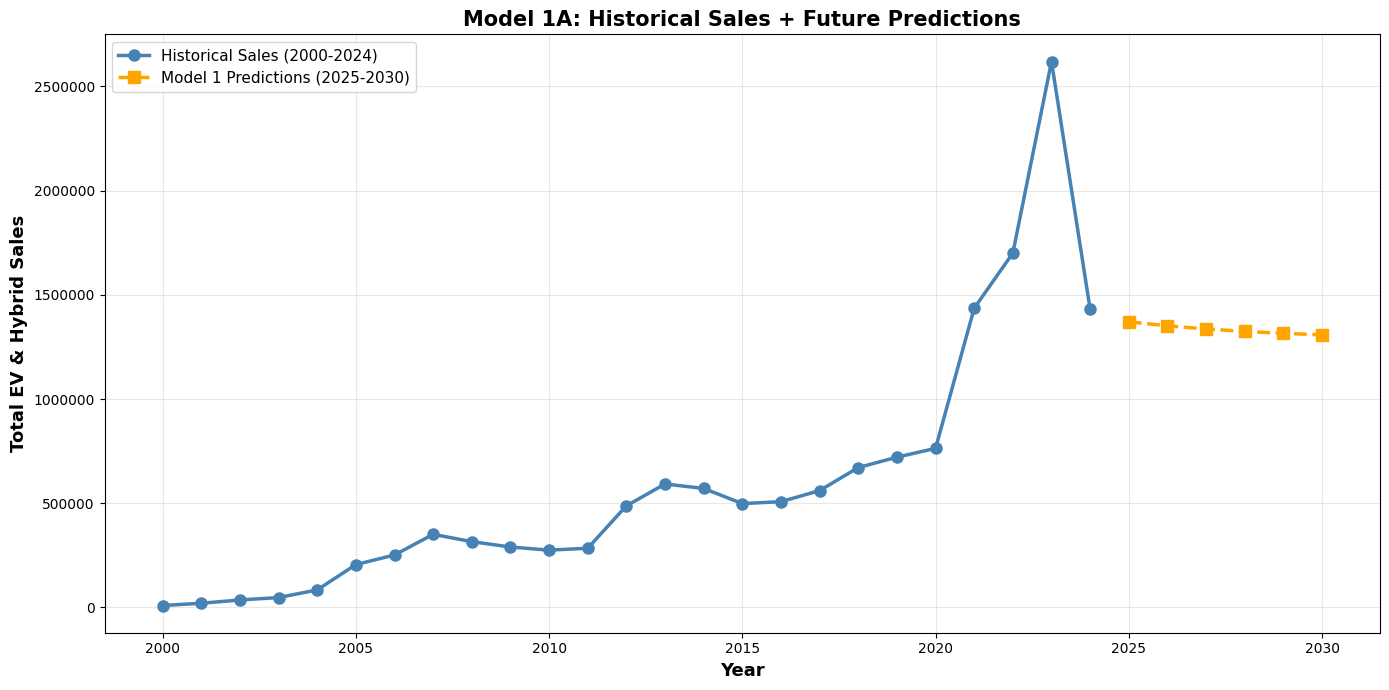


Future Predictions:
 year  predicted_sales
 2025     1.370669e+06
 2026     1.351481e+06
 2027     1.336457e+06
 2028     1.324694e+06
 2029     1.315484e+06
 2030     1.308272e+06


In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Historical data
plt.plot(merged['year'], merged['total_sales'],
         marker='o', linewidth=2.5, markersize=8,
         label='Historical Sales (2000-2024)', color='steelblue')

# Future predictions
plt.plot(future_df['year'], future_df['predicted_sales'],
         marker='s', linewidth=2.5, markersize=8, linestyle='--',
         label='Model 1 Predictions (2025-2030)', color='orange')

plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Total EV & Hybrid Sales', fontsize=13, fontweight='bold')
plt.title('Model 1A: Historical Sales + Future Predictions', fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

print("\nFuture Predictions:")
print(future_df.to_string(index=False))

## Observation: What Does Model 1A Tell Us?

**The Predictions:**
- 2025: ~1.37 million vehicles
- 2030: ~1.31 million vehicles
- Trend: Slight decline (-8.5%)

**Key Insights:**

1. **Conservative forecast** - The model predicts declining sales because 2024 (1.43M) was lower than 2023 (2.62M), and it assumes this trend continues.

2. **Momentum matters** - The coefficient of 0.78 for sales_lag1 means the model expects 78% of last year's trend to carry forward.

3. **Gas prices have impact** - Every $1 increase in gas price adds ~94,500 vehicles in sales.

**Limitations:**
- Doesn't account for new EV models, government incentives, battery tech improvements, or charging infrastructure
- Assumes linear relationships (reality might be more complex)
- Follows recent downward trend blindly (2024 dip might be temporary)
- Can't predict external shocks (recessions, policy changes)

**My Expectations:** I was expecting to see higher growth in the predictions. Looking at the early 2000s compared to now, the electric car market has changed dramatically - back then, EVs were barely known, but now they're mainstream with much better technology, more models available, and growing infrastructure. The 2024 dip was likely temporary, caused by factors like economic uncertainty and high interest rates, not a permanent trend reversal. Industry experts generally expect continued growth in EV adoption, not decline.

## **1A Conclusion + Next setup for 1B** ##

One of the reasons why I think our prediction showed a steady decline was because the model trained on 2000-2024 data, which had very steady, gradual growth in the early years. However, 2020-2024 had explosive ups and downs. Considering the electric car market and how familiar EVs were in the early 2000s compared to now, there is a very noticeable change.

Given this observation, I concluded that using only 2020-2024 data to predict 2025-2030 might be more appropriate. Would training on just recent years bring higher accuracy with different results?

In [69]:
## Step 1: Filter to Recent Data (only years 2020-2024)

# Filter to recent years only
df_recent = merged[merged['year'] >= 2020].copy()

print(f"Filtered dataset: {df_recent['year'].min()} to {df_recent['year'].max()}")
print(f"Total years: {len(df_recent)}")

print("\nRecent data:")
print(df_recent[['year', 'gas_price', 'total_sales']])

Filtered dataset: 2020 to 2024
Total years: 5

Recent data:
    year gas_price  total_sales
20  2020     2.225     763594.0
21  2021      2.87    1436252.0
22  2022      4.04    1700567.0
23  2023    3.5775    2619728.0
24  2024    3.3725    1430282.0


In [70]:
## Step 2: Create Lag Features

# Create lag features
df_recent["sales_lag1"] = df_recent["total_sales"].shift(1)
df_recent["gas_price_lag1"] = df_recent["gas_price"].shift(1)

# Drop first row (no previous year)
df_model1b = df_recent.dropna(subset=["sales_lag1", "gas_price_lag1"])

print("Training data for Model 1b (after creating lags):")
print(df_model1b[['year', 'total_sales', 'sales_lag1', 'gas_price', 'gas_price_lag1']])



Training data for Model 1b (after creating lags):
    year  total_sales  sales_lag1 gas_price gas_price_lag1
21  2021    1436252.0    763594.0      2.87          2.225
22  2022    1700567.0   1436252.0      4.04           2.87
23  2023    2619728.0   1700567.0    3.5775           4.04
24  2024    1430282.0   2619728.0    3.3725         3.5775


In [71]:
## Step 3: Train Model (0nly using years 2020 - 2024)

# Prepare features and target
X_recent = df_model1b[["sales_lag1", "gas_price_lag1"]]
y_recent = df_model1b["total_sales"]

# Train Model 1b
model1b = LinearRegression()
model1b.fit(X_recent, y_recent)

# Show equation
print("Model 1b Equation:")
print(f"predicted_sales = {model1b.coef_[0]:.4f} × sales_lag1")
print(f"                + {model1b.coef_[1]:.2f} × gas_price_lag1")
print(f"                + {model1b.intercept_:.2f}")

print("\n" + "="*70)
print("COMPARISON TO MODEL 1:")
print("="*70)
print(f"Model 1 (2000-2024):  {model1.coef_[0]:.4f} × sales_lag1 + {model1.coef_[1]:.2f} × gas_price_lag1")
print(f"Model 1b (2020-2024): {model1b.coef_[0]:.4f} × sales_lag1 + {model1b.coef_[1]:.2f} × gas_price_lag1")

Model 1b Equation:
predicted_sales = -0.7639 × sales_lag1
                + 1028997.87 × gas_price_lag1
                + -228440.58

COMPARISON TO MODEL 1:
Model 1 (2000-2024):  0.7830 × sales_lag1 + 94516.59 × gas_price_lag1
Model 1b (2020-2024): -0.7639 × sales_lag1 + 1028997.87 × gas_price_lag1


In [72]:
## Step 4: Predict 2025-2030 with Model 1b

# Get 2024 starting values
last_year_sales_b = df_model1b[df_model1b['year'] == 2024]['total_sales'].values[0]
last_year_gas_price_b = df_model1b[df_model1b['year'] == 2024]['gas_price'].values[0]

# Assume future gas prices
assumed_gas_price_b = df_model1b.tail(3)['gas_price'].mean()

print(f"Starting from 2024:")
print(f"  - Sales: {last_year_sales_b:,.0f}")
print(f"  - Gas price: ${last_year_gas_price_b:.2f}")
print(f"  - Assuming future gas price: ${assumed_gas_price_b:.2f}\n")

# Predict 2025-2030
future_years_b = []
future_predictions_b = []

for year in range(2025, 2031):
    features_b = pd.DataFrame([[last_year_sales_b, last_year_gas_price_b]],
                              columns=['sales_lag1', 'gas_price_lag1'])

    prediction_b = model1b.predict(features_b)[0]

    future_years_b.append(year)
    future_predictions_b.append(prediction_b)

    print(f"{year}: {prediction_b:,.0f} vehicles")

    # Update for next year
    last_year_sales_b = prediction_b
    last_year_gas_price_b = assumed_gas_price_b

# Save predictions
future_df_b = pd.DataFrame({
    'year': future_years_b,
    'predicted_sales': future_predictions_b
})

Starting from 2024:
  - Sales: 1,430,282
  - Gas price: $3.37
  - Assuming future gas price: $3.66

2025: 2,149,304 vehicles
2026: 1,899,331 vehicles
2027: 2,090,278 vehicles
2028: 1,944,419 vehicles
2029: 2,055,837 vehicles
2030: 1,970,728 vehicles


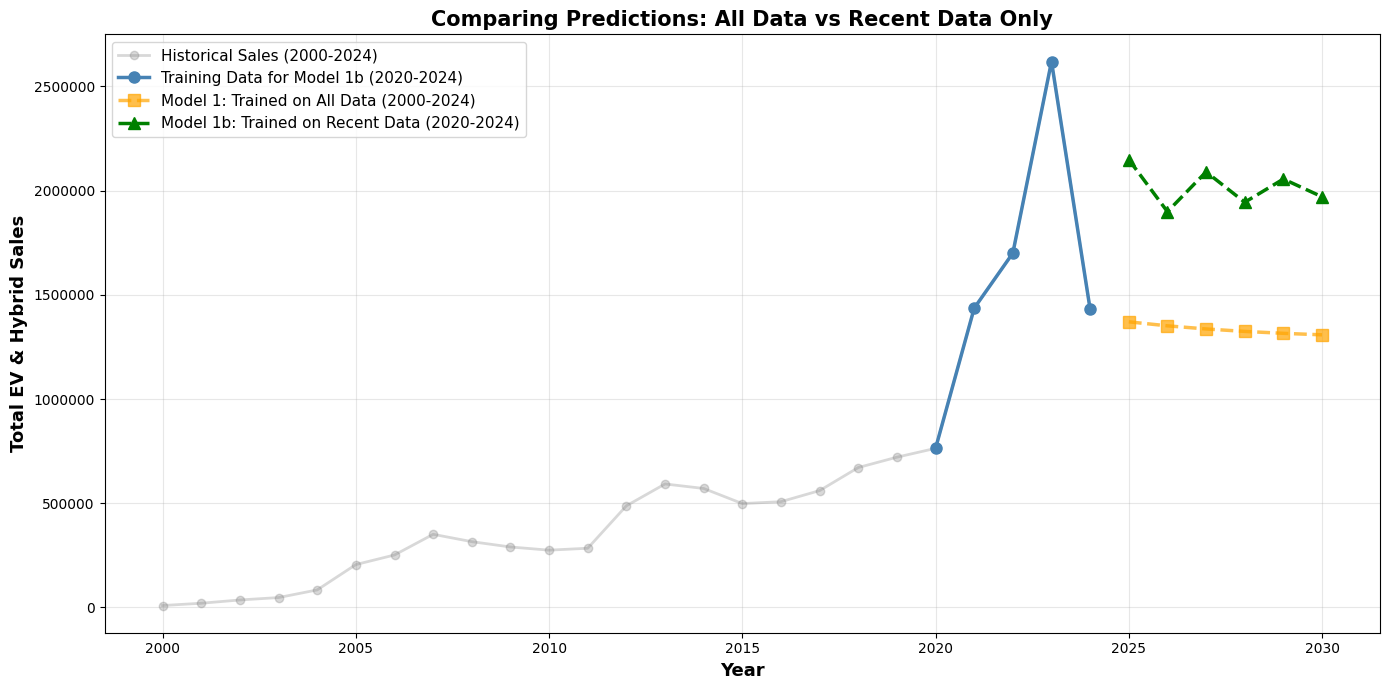

In [73]:
## Step 5: Compare Both Models Visually

plt.figure(figsize=(14, 7))

# All historical data in gray
plt.plot(merged['year'], merged['total_sales'],
         marker='o', linewidth=2, markersize=6, alpha=0.3,
         label='Historical Sales (2000-2024)', color='gray')

# Highlight recent training period
recent_data = merged[merged['year'] >= 2020]
plt.plot(recent_data['year'], recent_data['total_sales'],
         marker='o', linewidth=2.5, markersize=8,
         label='Training Data for Model 1b (2020-2024)', color='steelblue')

# Model 1 predictions
plt.plot(future_df['year'], future_df['predicted_sales'],
         marker='s', linewidth=2.5, markersize=8, linestyle='--',
         label='Model 1: Trained on All Data (2000-2024)', color='orange', alpha=0.7)

# Model 1b predictions
plt.plot(future_df_b['year'], future_df_b['predicted_sales'],
         marker='^', linewidth=2.5, markersize=8, linestyle='--',
         label='Model 1b: Trained on Recent Data (2020-2024)', color='green')

plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Total EV & Hybrid Sales', fontsize=13, fontweight='bold')
plt.title('Comparing Predictions: All Data vs Recent Data Only', fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [74]:
# Create comparison table
comparison = pd.DataFrame({
    'Year': future_df['year'],
    'Model 1 (2000-2024)': future_df['predicted_sales'].astype(int),
    'Model 1b (2020-2024)': future_df_b['predicted_sales'].astype(int),
    'Difference': (future_df_b['predicted_sales'] - future_df['predicted_sales']).astype(int)
})

print("Prediction Comparison:")
print(comparison.to_string(index=False))

print(f"\n Summary:")
print(f"  Model 1 (2000-2024) - 2030 prediction: {future_df['predicted_sales'].iloc[-1]:,.0f}")
print(f"  Model 1b (2020-2024) - 2030 prediction: {future_df_b['predicted_sales'].iloc[-1]:,.0f}")
print(f"  Difference: {(future_df_b['predicted_sales'].iloc[-1] - future_df['predicted_sales'].iloc[-1]):,.0f} vehicles")

Prediction Comparison:
 Year  Model 1 (2000-2024)  Model 1b (2020-2024)  Difference
 2025              1370668               2149304      778635
 2026              1351480               1899331      547850
 2027              1336457               2090278      753821
 2028              1324693               1944419      619725
 2029              1315483               2055836      740353
 2030              1308271               1970728      662456

 Summary:
  Model 1 (2000-2024) - 2030 prediction: 1,308,272
  Model 1b (2020-2024) - 2030 prediction: 1,970,728
  Difference: 662,456 vehicles


## Observation: What Did I Learn?

**Huge difference in predictions:**
- Model 1 (2000-2024): Predicts ~1.31M by 2030 (declining trend)
- Model 1b (2020-2024): Predicts ~1.97M by 2030 (oscillating, much higher)
- Difference: Model 1b is 660,000+ vehicles higher!

**Why such different results?**

1. **Training data matters**: Model 1 learns from 20+ years including slow-growth early years, while Model 1b only sees recent explosive growth

2. **Small dataset problem**: Model 1b has only 4 training points (2021-2024 after creating lags). This is NOT enough data for reliable predictions.

3. **Unstable coefficients - The 2024 crash effect**: Model 1b has a negative coefficient on sales_lag1 (-0.76), meaning "high sales last year → low sales this year." This doesn't make economic sense - it's the model overfitting to the 2023→2024 decline. Looking at the training data:
   - 2020 → 2021: Sales grew from 764K to 1.4M
   - 2021 → 2022: Sales grew from 1.4M to 1.7M  
   - 2022 → 2023: Sales grew from 1.7M to 2.6M
   - 2023 → 2024: Sales DROPPED from 2.6M to 1.4M
   
   With only 4 data points, the 2024 crash has huge influence. The model sees "when last year had very high sales (2.6M), this year crashed (1.4M)" and assumes this is a permanent pattern, not a temporary dip. This creates the negative coefficient and oscillating predictions.

4. **Extreme gas price sensitivity**: Model 1b's gas price coefficient is 10x higher than Model 1, showing the model is trying to explain recent volatility through gas prices alone.

**Which model is better?**

Neither is perfect:
- **Model 1 is too conservative**: Weighted down by irrelevant early data
- **Model 1b is too unstable**: Not enough data, overfits to recent noise

**The lesson:**
- Using all historical data can include irrelevant patterns
- Using too little data leads to overfitting and unreliable predictions  
- The "right" amount of training data depends on when the market fundamentally changed

**My Expectations**: I was expecting Model 1b to show higher growth since the 2020-2024 period had such explosive growth. Looking at the early 2000s compared to now, the electric car market has changed dramatically - back then, EVs were barely known, but now they're mainstream with much better technology, more models available, and growing infrastructure. However, the negative coefficient surprised me. The 2024 dip was likely temporary, caused by factors like economic uncertainty and high interest rates, not a permanent trend reversal. I expected the model to capture the overall upward momentum of 2020-2023, but instead it got stuck on the 2024 crash.

## **Next setup 1C** ##

My next question after seeing the huge difference in predictions between Model 1 (2000-2024) and Model 1b (2020-2024) was: what if we explore how gas prices affect the predictions?

When it comes to gas prices, they're really unpredictable because a lot of factors go into them - different countries, wars, the economy, new government policies, etc. From Model 1, we saw that each 1 dollar increase in gas price adds about 94,517 EV sales (from the linear regression coefficient).

So for Model 1C, I wanted to test three different gas price scenarios using the 2000-2024 training data (Model 1's stable foundation):

- Low gas price: 1.66 dollar (baseline minus 2.00 dollar)

- Baseline: 3.66 dollar (average of 2022, 2023, 2024)

- High gas price: 5.66 dollar (baseline plus 2.00 dollar)

This would show how sensitive future EV sales are to gas price changes.

In [75]:
## Gas Price Scenario Analysis (different prices 1.66 dollars(-2)  |  3.66 dollars(average price "(2022+2023+2024)/3"  |  5.66 dollars(+2))

# Define three gas price scenarios
baseline_gas = 3.66
low_gas = baseline_gas - 2.00      # $1.66
high_gas = baseline_gas + 2.00     # $5.66

scenarios = {
    'Low Gas Price ($1.66)': low_gas,
    'Baseline ($3.66)': baseline_gas,
    'High Gas Price ($5.66)': high_gas
}

print("Gas Price Scenarios:")
for name, price in scenarios.items():
    print(f"  {name}: ${price:.2f}")



Gas Price Scenarios:
  Low Gas Price ($1.66): $1.66
  Baseline ($3.66): $3.66
  High Gas Price ($5.66): $5.66


In [76]:
# Store results for each scenario
scenario_results = {}

# Get starting values from 2024
start_sales = df_model1[df_model1['year'] == 2024]['total_sales'].values[0]
start_gas = df_model1[df_model1['year'] == 2024]['gas_price'].values[0]

print(f"Starting from 2024:")
print(f"  Sales: {start_sales:,.0f}")
print(f"  Gas price: ${start_gas:.2f}\n")

# Run predictions for each scenario
for scenario_name, gas_price in scenarios.items():
    print(f"\n{'='*70}")
    print(f"{scenario_name}")
    print('='*70)

    # Reset to 2024 starting values
    last_year_sales = start_sales
    last_year_gas_price = start_gas

    future_years = []
    future_predictions = []

    # Predict 2025-2030
    for year in range(2025, 2031):
        # Create features
        features = pd.DataFrame([[last_year_sales, last_year_gas_price]],
                               columns=['sales_lag1', 'gas_price_lag1'])

        # Make prediction
        prediction = model1.predict(features)[0]

        future_years.append(year)
        future_predictions.append(prediction)

        print(f"{year}: {prediction:,.0f} vehicles")

        # Update for next year
        last_year_sales = prediction
        last_year_gas_price = gas_price  # Use scenario gas price

    # Store results
    scenario_results[scenario_name] = {
        'years': future_years,
        'predictions': future_predictions
    }

Starting from 2024:
  Sales: 1,430,282
  Gas price: $3.37


Low Gas Price ($1.66)
2025: 1,370,669 vehicles
2026: 1,162,133 vehicles
2027: 998,853 vehicles
2028: 871,007 vehicles
2029: 770,906 vehicles
2030: 692,529 vehicles

Baseline ($3.66)
2025: 1,370,669 vehicles
2026: 1,351,166 vehicles
2027: 1,335,895 vehicles
2028: 1,323,939 vehicles
2029: 1,314,577 vehicles
2030: 1,307,247 vehicles

High Gas Price ($5.66)
2025: 1,370,669 vehicles
2026: 1,540,199 vehicles
2027: 1,672,938 vehicles
2028: 1,776,871 vehicles
2029: 1,858,249 vehicles
2030: 1,921,966 vehicles


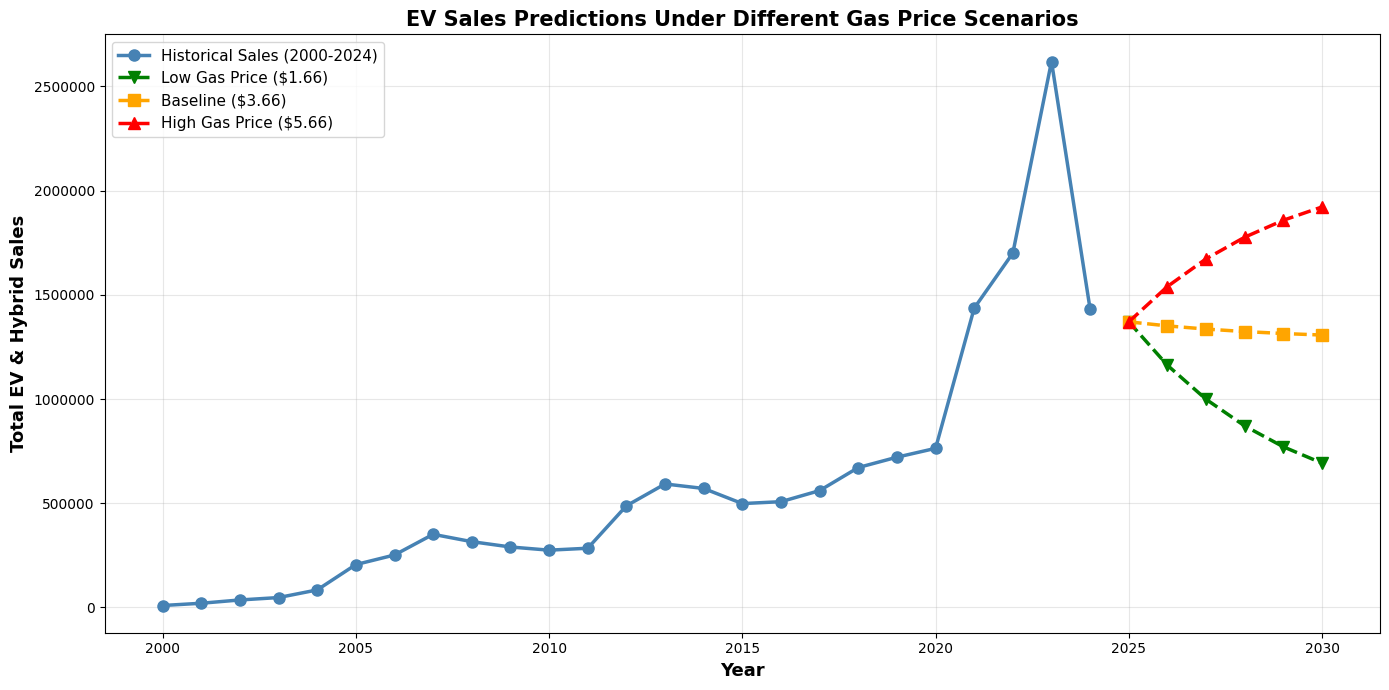

In [77]:
## Visualize All Three Scenarios

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(merged['year'], merged['total_sales'],
         marker='o', linewidth=2.5, markersize=8,
         label='Historical Sales (2000-2024)', color='steelblue')

# Plot each scenario with different colors
colors = ['green', 'orange', 'red']
markers = ['v', 's', '^']
linestyles = ['--', '--', '--']

for (scenario_name, results), color, marker, linestyle in zip(scenario_results.items(), colors, markers, linestyles):
    plt.plot(results['years'], results['predictions'],
             marker=marker, linewidth=2.5, markersize=8,
             linestyle=linestyle, color=color, label=scenario_name)

plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Total EV & Hybrid Sales', fontsize=13, fontweight='bold')
plt.title('EV Sales Predictions Under Different Gas Price Scenarios', fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [78]:
# Create comparison table
comparison_data = []
for scenario_name, results in scenario_results.items():
    prediction_2030 = results['predictions'][-1]  # Last year (2030)
    comparison_data.append({
        'Scenario': scenario_name,
        '2030 Prediction': int(prediction_2030)
    })

comparison_df = pd.DataFrame(comparison_data)

print("2030 Sales Predictions by Scenario:")
print(comparison_df.to_string(index=False))

# Calculate differences
baseline_2030 = scenario_results['Baseline ($3.66)']['predictions'][-1]
low_2030 = scenario_results['Low Gas Price ($1.66)']['predictions'][-1]
high_2030 = scenario_results['High Gas Price ($5.66)']['predictions'][-1]

print(f"\n  Impact of Gas Price Changes:")
print(f"  Low vs Baseline: {int(low_2030 - baseline_2030):,} vehicles ({(low_2030/baseline_2030 - 1)*100:.1f}%)")
print(f"  High vs Baseline: {int(high_2030 - baseline_2030):,} vehicles ({(high_2030/baseline_2030 - 1)*100:.1f}%)")
print(f"  High vs Low: {int(high_2030 - low_2030):,} vehicles ({(high_2030/low_2030 - 1)*100:.1f}%)")

2030 Sales Predictions by Scenario:
              Scenario  2030 Prediction
 Low Gas Price ($1.66)           692529
      Baseline ($3.66)          1307247
High Gas Price ($5.66)          1921965

  Impact of Gas Price Changes:
  Low vs Baseline: -614,718 vehicles (-47.0%)
  High vs Baseline: 614,718 vehicles (47.0%)
  High vs Low: 1,229,436 vehicles (177.5%)


## Observation: What Does Model 1C Tell Us?

Looking at the three different gas price scenarios, here's what I learned:

**Gas prices significantly impact EV adoption:**

The difference between low and high gas price scenarios shows that fuel costs are a major factor in EV purchasing decisions. When gas is expensive, more people switch to EVs to save money on fuel.

**Key insights:**

1. **Extreme sensitivity to gas prices**: The model shows dramatic differences depending on gas prices:
   - Low gas (1.66 dollar): ~693K by 2030
   - Baseline (3.66 dollar): ~1.31M by 2030
   - High gas (5.66 dollar): ~1.92M by 2030
   - A $4 difference in gas prices results in over 1.2 million vehicles difference (178% increase from low to high)!

2. **Confirms earlier findings**: This ties back to when we compared the historical data and saw the relationship between gas prices and EV sales. Higher gas prices consistently correlate with increased EV adoption, and these scenarios confirm that pattern holds for future predictions as well.

3. **Real-world implications**:
   - If oil prices spike (due to geopolitical tensions, production cuts, or carbon taxes), EV adoption could accelerate faster than the baseline prediction
   - If oil prices drop (new discoveries, increased production, economic recession), EV adoption might slow down

**Limitations:**

- Gas prices don't stay constant - they fluctuate monthly. These scenarios assume constant prices for 6 years, which is unrealistic.
- Other factors matter too: government incentives, new EV models, battery technology improvements, charging infrastructure expansion
- The model's coefficient is based on historical data and might not hold in the future if the market changes dramatically

**What this means for predictions:**

My baseline prediction ($3.66 gas) should be viewed as just one possibility. The actual outcome depends heavily on future gas prices, which are uncertain and influenced by global events beyond anyone's control. The low and high scenarios show the potential range - from conservative growth to explosive adoption depending on fuel costs.

# Final Report/Observation for this Final Project

**Reflection:**

I remember Professor Santos emphasizing how important it is to choose the right dataset. When we are working with multiple datasets, it's very important to research each one in depth and make sure the information is reliable and relevant to the question we want to answer. I spent a lot of time looking through different sources to find the most accurate and consistent data—especially because I want to continue this project and possibly use it for my resume. I wanted my analysis to be clear, honest, and based on trustworthy data.

At first, I considered using international datasets, but different countries have different reporting styles, different policies, and too many variables that could make the results confusing. Because of that, I chose to focus only on the United States. This made the data more consistent and easier to compare. The emissions data came from the U.S. Department of Transportation, gasoline price data came from the U.S. Department of Energy, and EV/Hybrid sales data also came from the U.S. Department of Transportation. I chose these sources because they are reliable and widely used for policy and research.

**Initial Analysis:**

Throughout the initial analysis, I noticed that the graphs revealed some meaningful trends. For example, when comparing gasoline prices with total EV/Hybrid sales, there seems to be a positive correlation: when gasoline prices go up, EV/Hybrid sales also tend to increase. However, even though the trend looks related, it's important to remember that this does not necessarily mean gasoline prices directly caused the increase in EV sales. Other factors—such as new EV model releases, government incentives, and improvements in charging infrastructure—could also play a big role.

On the emissions graph as well, the pattern is clear that both CO₂ and NOx emissions steadily decrease over time, while EV/Hybrid sales increase. This suggests that the shift toward electric and hybrid vehicles is likely contributing to cleaner air and lower pollution levels. However, we also need to consider that other factors may be involved, such as improvements in engine technology, fuel standards, and emissions regulations. We cannot fully confirm that the decrease in CO₂ and NOx comes directly from the increase in EV/Hybrid sales.

**Predictive Modeling:**

Building on the initial analysis, I developed predictive models using lag features to forecast future EV sales from 2025-2030. Lag features use data from the previous year (last year's sales and gas prices) to predict the current year's sales, capturing the momentum and patterns in the market. I explored three different approaches:

**Model 1A (2000-2024):** Using the full historical dataset with lag features, this model predicted relatively conservative growth to around 1.3M vehicles by 2030. The model learned that 78% of last year's sales momentum carries forward, and each $1 increase in gas price adds about 94,500 vehicles. With stable coefficients trained on 24 years of data, this model provides reliable baseline predictions.

**Model 1b (2020-2024):** Using only recent data with the same lag feature approach, this model produced very different results with oscillating predictions around 2.0M vehicles. However, I discovered a critical issue: with only 4 training points (2021-2024), the model developed a negative coefficient for sales momentum (-0.76). This happened because the 2024 crash (from 2.6M to 1.4M) dominated the small dataset, causing the model to assume high sales lead to crashes. This showed me that too little training data leads to unreliable predictions, especially with lag features.

**Model 1C (Gas Price Scenarios):** Using the stable Model 1 foundation with lag features, I tested how different gas price scenarios would affect future EV sales:
- Low gas (1.66 dollar): ~693K by 2030
- Baseline (3.66 dollar): ~1.31M by 2030  
- High gas (5.66 dollar): ~1.92M by 2030

The $4 difference in gas prices resulted in over 1.2 million vehicles difference, demonstrating how critical fuel costs are to EV adoption.

**Key Lessons Learned:**

1. **Training data selection matters:** Using all historical data (2000-2024) provides stability, but using too little data (2020-2024) leads to overfitting and unreliable predictions. The "right" amount depends on when the market fundamentally changed.

2. **Gas prices are a major driver:** The scenario analysis clearly shows that fuel costs significantly influence EV purchasing decisions. Economic factors play a crucial role in whether people switch to electric vehicles.

3. **Patterns don't prove direct cause:** While I found strong correlations among gasoline prices, EV/Hybrid sales, and emissions reductions, other factors could also play a role in each trend.

4. **Models have limitations:** Predictions assume constant gas prices and can't account for future policy changes, technological breakthroughs, or market disruptions. They should be viewed as possible scenarios rather than guaranteed outcomes.

**Overall Conclusion:**

Through this project, I found meaningful relationships among the three main factors: gasoline price, EV/Hybrid sales, and emissions. When gasoline prices increased, we saw an increase in EV/Hybrid sales, and that rise in EV/Hybrid sales corresponded with emissions going down over the years. The predictive modeling extended these insights into the future, showing that gas prices could be one of the most critical factors determining the pace of EV adoption through 2030.

This project helped me understand the importance of carefully selecting datasets, cleaning them, reshaping them properly, and choosing the right visualizations to tell a clear story. It also showed how data can reveal meaningful relationships when it's analyzed the right way, while also highlighting the limitations of purely statistical approaches. I learned a lot from this process, and the experience has given me practical skills in data analysis and predictive modeling that I can apply to future projects.